# **Complete repository step-by-step diagnostics.**

In [1]:
from typing import Any, Callable, Optional
from rich import print
import yaml
from PIL import Image

def validate_call(label: str, expected_valid: bool, func: Callable, *args: Any, **kwargs: Any) -> Optional[Any]:
    try:
        result = func(*args, **kwargs)
    except Exception as exc:
        if expected_valid:
            print(f"[bold red][EXCEPTION] {label}: Expected success but crashed with {type(exc).__name__}({exc})[/bold red]")
        else:
            print(f"[bold cyan][REJECTED] {label}: Safely blocked with {type(exc).__name__}({exc})[/bold cyan]")
        return None
    else:
        if expected_valid:
            print(f"[bold green][VALIDATED] {label}: Executed successfully.[/bold green]")
            return result
        print(f"[bold magenta][FALSE POSITIVE] {label}: Expected rejection but execution succeeded.[/bold magenta]")
        return result

def assert_true(condition: bool, message: str) -> bool:
    if not condition:
        raise AssertionError(message)
    return True

def set_layer(edge: Any, layer: int) -> Any:
    setattr(edge, "layer", layer)
    return edge

def assert_square_image(image: Image.Image) -> bool:
    return assert_true(image.width == image.height, "Image must be square.")

def load_yaml_config(path: str) -> Any:
    with open(path, "r", encoding="utf-8") as file:
        return yaml.safe_load(file)


## **Node** (in node.py)

[VALIDATED] Node(124.2, 8.2, 0): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 1): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 2): Executed successfully.

[VALIDATED] Node(124.2, 8.2, 3): Executed successfully.

[VALIDATED] Node(124.2, 8.2, None): Executed successfully.

...

[REJECTED] Node(124.2, 91, 0): Safely blocked with ValueError([NODE] Invalid lat value 91. Must be a number from 
-90 to 90.)

[REJECTED] Node(124.2, -91, 0): Safely blocked with ValueError([NODE] Invalid lat value -91. Must be a number from 
-90 to 90.)

[VALIDATED] Node identity and immutability: Executed successfully.

[VALIDATED] Node visualization square image: Executed successfully.

[VALIDATED] Node square check: Executed successfully.

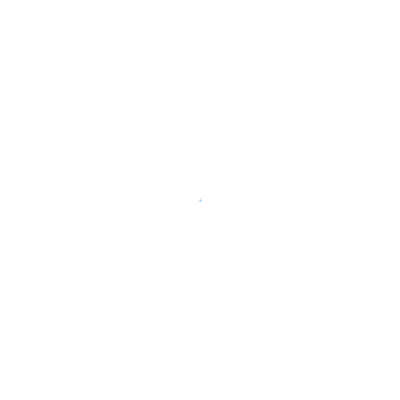

In [2]:
from utils.node import Node
from IPython.display import display

node_cases = [
    (124.2, 8.2, 0, True),
    (124.2, 8.2, 1, True),
    (124.2, 8.2, 2, True),
    (124.2, 8.2, 3, True),
    (124.2, 8.2, None, True),
]

for lon, lat, layer, expected in node_cases:
    label = f"Node({lon}, {lat}, {layer})"
    if layer is None:
        validate_call(label, expected, Node, lon, lat)
    else:
        validate_call(label, expected, Node, lon, lat, layer)

for lon, lat, layer in [(124.2, 8.2, 4), (124.2, 8.2, -1)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

for lon, lat, layer in [(181, 8.2, 0), (-181, 8.2, 0), (124.2, 91, 0), (124.2, -91, 0)]:
    validate_call(f"Node({lon}, {lat}, {layer})", False, Node, lon, lat, layer)

def verify_node_contract() -> bool:
    n1 = Node(124.2, 8.2, 0)
    n2 = Node(124.2, 8.2, 0)

    assert_true(n1.id != n2.id, "Node IDs should be unique")
    assert_true(isinstance(n1.id, str) and n1.id.startswith("N"), "Node ID should be a string")
    assert_true(n1.lon == 124.2 and n1.lat == 8.2, "Node coordinates should be preserved")

    try:
        n1.lon = 125.0
        raise AssertionError("Node.lon should be immutable")
    except AttributeError:
        pass

    return True

validate_call("Node identity and immutability", True, verify_node_contract)

img = validate_call("Node visualization square image", True, lambda: Node(124.2, 8.2).draw(((124.1, 8.3), (124.3, 8.1)), Image.new("RGB", (400, 400), "white")))
if img:
    validate_call("Node square check", True, assert_square_image, img)
    display(img)


## **DirEdge** (in directed_edge.py)

[VALIDATED] DirEdge L1 same-layer: Executed successfully.

[VALIDATED] DirEdge L2 same-layer: Executed successfully.

[VALIDATED] DirEdge cross-layer 1->2: Executed successfully.

[REJECTED] DirEdge identical nodes: Safely blocked with ValueError([DIR EDGE] Start and end nodes cannot be 
identical.)

[REJECTED] DirEdge cross-layer diff coords: Safely blocked with ValueError([DIR EDGE] Start and end nodes on 
different layers must have same coordinates.)

...

[REJECTED] DirEdge None end: Safely blocked with ValueError([DIR EDGE] No end node provided.)

[REJECTED] DirEdge None both: Safely blocked with ValueError([DIR EDGE] No start and end node provided.)

[VALIDATED] Stitch populates next_edges: Executed successfully.

[VALIDATED] DirEdge draw: Executed successfully.

[VALIDATED] DirEdge square check: Executed successfully.

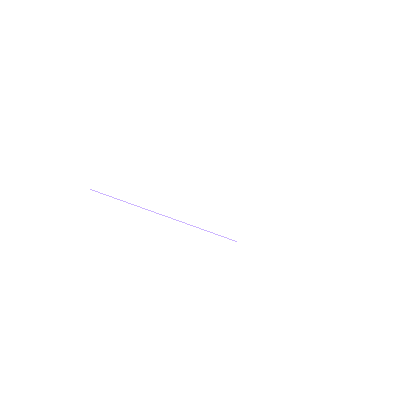

In [3]:
from utils.node import Node
from utils.directed_edge import DirEdge, _stitch
from IPython.display import display

n1l1 = Node(124.2384, 8.2393, 1)
n2l1 = Node(124.243862, 8.237768, 1)
n3l1 = Node(124.238, 8.239, 1)
n1l2 = Node(124.2384, 8.2393, 2)
n2l2 = Node(124.243862, 8.237768, 2)

# ── Positive: Valid same-layer edges
validate_call("DirEdge L1 same-layer", True, DirEdge, n1l1, n2l1)
validate_call("DirEdge L2 same-layer", True, DirEdge, n1l2, n2l2)

# ── Positive: Valid cross-layer (same coords, adjacent layers)
validate_call("DirEdge cross-layer 1->2", True, DirEdge, n1l1, n1l2)

# ── Negative: Identical nodes
validate_call("DirEdge identical nodes", False, DirEdge, n1l1, n1l1)

# ── Negative: Cross-layer with different coordinates (teleport)
validate_call("DirEdge cross-layer diff coords", False, DirEdge, n1l1, n2l2)

# ── Negative: None inputs
validate_call("DirEdge None start", False, DirEdge, None, n2l1)
validate_call("DirEdge None end", False, DirEdge, n1l1, None)
validate_call("DirEdge None both", False, DirEdge, None, None)

# ── Stitch test
e1 = DirEdge(n1l1, n2l1)
e2 = DirEdge(n2l1, n3l1)
e3 = DirEdge(n3l1, n1l1)
_stitch([e1, e2, e3], [e1, e2, e3])
validate_call("Stitch populates next_edges", True, assert_true, len(e1.next_edges) > 0, "next_edges should not be empty after stitch.")

# ── Visualization
ctx = ((124.235, 8.245), (124.25, 8.233))
base = Image.new("RGB", (400, 400), "white")
img = validate_call("DirEdge draw", True, e1.draw, ctx, base)
if img:
    validate_call("DirEdge square check", True, assert_square_image, img)
    display(img)


## **CityGraph** (in city_graph.py)

[REJECTED] BBOX Validation (Too Short): Safely blocked with ValueError([CITY GRAPH] Invalid bbox. Must be a tuple 
of 4 floats: (min_lat, max_lat, min_lon, max_lon).)

[VALIDATED] CityGraph Toy Init (Iligan subset): Executed successfully.

[VALIDATED] Node count > 0: Executed successfully.

[VALIDATED] Edge count > 0: Executed successfully.

[VALIDATED] CityGraph draw: Executed successfully.

[VALIDATED] CityGraph square check: Executed successfully.

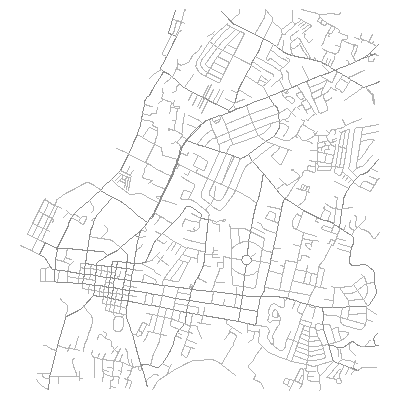

In [4]:
from utils.city_graph import CityGraph
from utils.node import Node
from utils.directed_edge import DirEdge
from IPython.display import display

# ── Negative: Invalid bbox
validate_call("BBOX Validation (Too Short)", False, CityGraph, bbox=(8.2,))

# ── Positive: Toy graph for unit-level contract testing
MOCK_BBOX = (8.22, 8.25, 124.23, 124.26)
LOCAL_PBF_PATH = "utils/data/iligan-city.pbf"

cg = validate_call(
    "CityGraph Toy Init (Iligan subset)",
    True, CityGraph,
    bbox=MOCK_BBOX, name="Iligan Subset", pbf_path=LOCAL_PBF_PATH
)

if cg:
    validate_call("Node count > 0", True, assert_true, len(cg.nodes) > 0, "Graph has no nodes.")
    validate_call("Edge count > 0", True, assert_true, len(cg.graph) > 0, "Graph has no edges.")
    
    img = validate_call("CityGraph draw", True, cg.draw, size=400)
    if img:
        validate_call("CityGraph square check", True, assert_square_image, img)
        display(img)


[CITY GRAPH] Loading graph from binary cache.


[CITY GRAPH] Building edges: 100%|██████████| 75761/75761 [00:00<00:00, 100727.51it/s]


[VALIDATED] Iligan CityGraph Initialization: Executed successfully.

[VALIDATED] Iligan All Edges: Executed successfully.

[VALIDATED] Iligan Drivable Only: Executed successfully.

[VALIDATED] All Edges square check: Executed successfully.

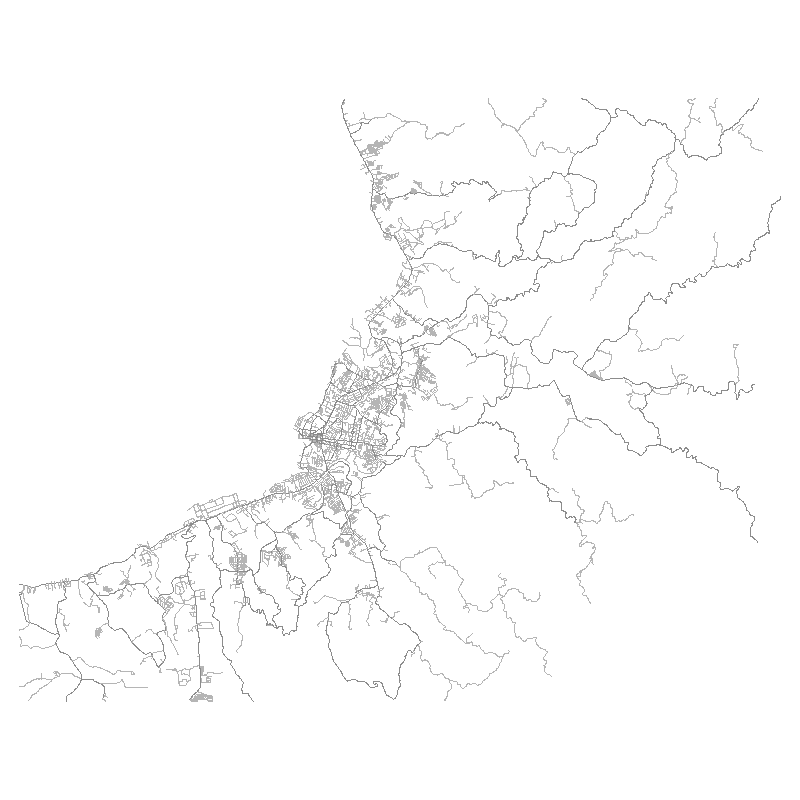

[VALIDATED] Drivable Only square check: Executed successfully.

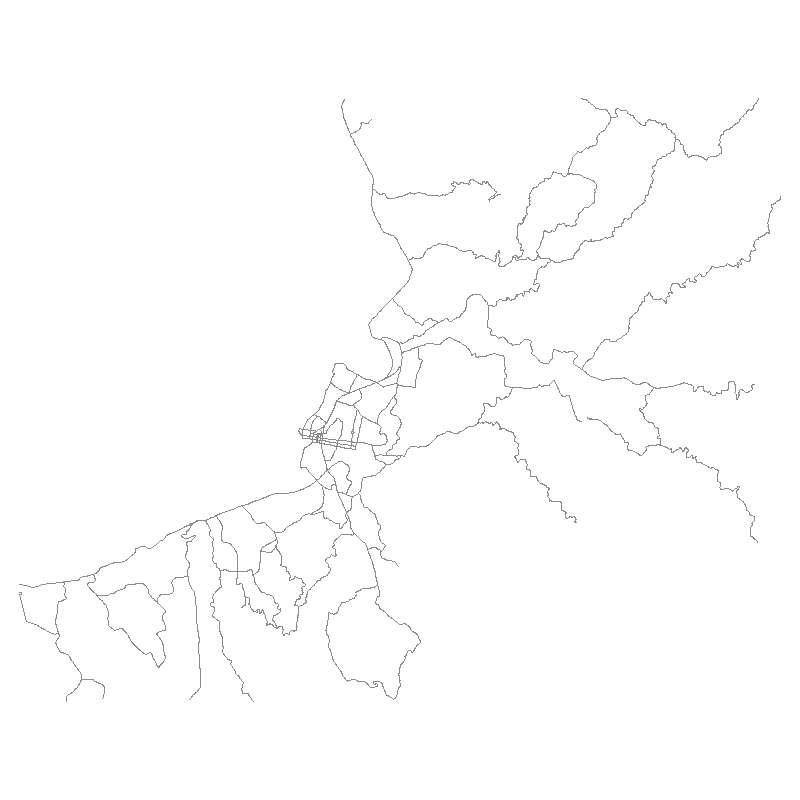

In [5]:
from IPython.display import display

cfg = load_yaml_config("configs/iligan_configs.yaml")
city_graph_cfg = cfg["city_graph"]

city = validate_call(
    "Iligan CityGraph Initialization",
    True,
    CityGraph,
    bbox=tuple(city_graph_cfg["bbox"]),
    name=city_graph_cfg["name"],
    landmarks=city_graph_cfg["landmarks"],
    pbf_path=city_graph_cfg["pbf_path"],
    use_api=False,
    verbose=True,
)

if city:
    all_img = validate_call("Iligan All Edges", True, city.draw, size=800, only_drivable=False)
    drv_img = validate_call("Iligan Drivable Only", True, city.draw, size=800, only_drivable=True)
    
    if all_img:
        validate_call("All Edges square check", True, assert_square_image, all_img)
        display(all_img)
    if drv_img:
        validate_call("Drivable Only square check", True, assert_square_image, drv_img)
        display(drv_img)


## **DirectDemandSampler** (in direct_demand_sampler.py)

[VALIDATED] TOMTOM API key present: Executed successfully.

[VALIDATED] Initialize DDM Sampler: Executed successfully.

[VALIDATED] Base map for density: Executed successfully.

[VALIDATED] Iligan bounding context: Executed successfully.

Traffic Density Spectrum Legend:

██ Low Traffic

██ Moderate Traffic

██ High Traffic

[VALIDATED] Draw DDM density heatmap: Executed successfully.

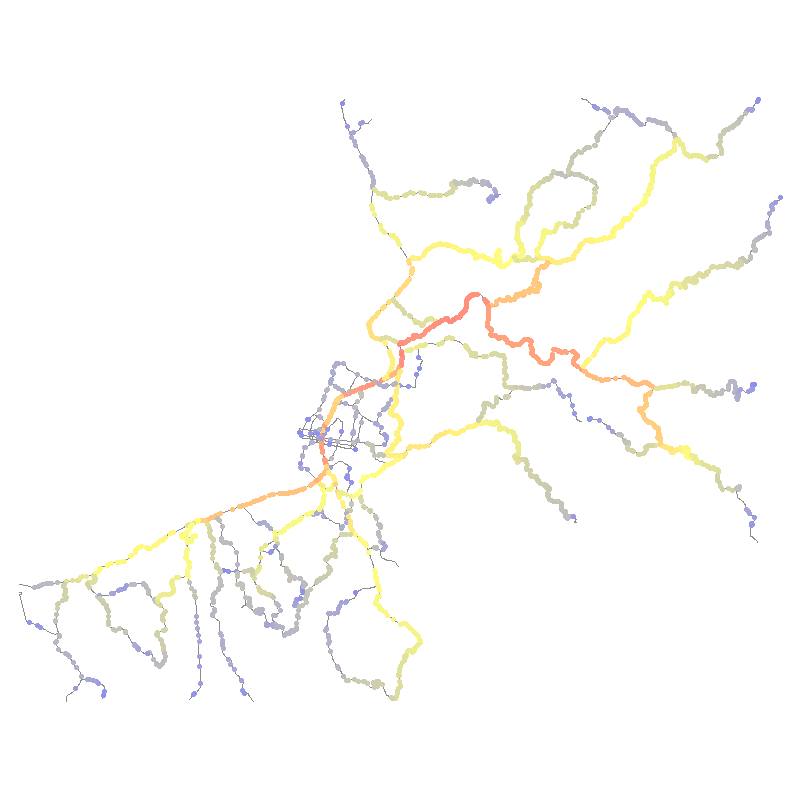

In [6]:
import os
from dotenv import load_dotenv
from IPython.display import display
from utils.direct_demand_sampler import DirectDemandSampler, DDMConfig

load_dotenv()
TOMTOM_API_KEY = os.getenv("TOMTOM_API_KEY")

if not TOMTOM_API_KEY:
    raise ValueError("[ENVIRONMENT] TOMTOM_API_KEY is missing from the .env file.")
else:
    validate_call("TOMTOM API key present", True, lambda: bool(TOMTOM_API_KEY))

if city and cfg:
    sampler = validate_call(
        "Initialize DDM Sampler",
        True,
        DirectDemandSampler,
        city=city,
        config=DDMConfig(**cfg["ddm"]),
        only_drivable=True
    )

    if sampler:
        # ── DDM density visualization
        base_img = validate_call("Base map for density", True, city.draw, size=800, only_drivable=True)
        context = validate_call("Iligan bounding context", True, city.get_bounds)
        
        if base_img and context:
            density_img = base_img.copy().convert("RGBA")
            validate_call("Draw DDM density heatmap", True, sampler.draw_density, density_img, context)
            display(density_img)


## **Route** (in route.py)

In [7]:
import copy
from utils.node import Node
from utils.directed_edge import DirEdge
from utils.route import Route, RouteGenerator
from IPython.display import display

# ── Route primitive contract tests (toy data, since Route is a primitive like Node/DirEdge)
class MockCityGraph:
    pass

mock_cg = MockCityGraph()

n1 = Node(124.2, 8.2, 2)
n2 = Node(124.3, 8.2, 2)
n3 = Node(124.3, 8.3, 2)
n4 = Node(124.2, 8.3, 2)
n_rogue = Node(0.0, 0.0, 2)

e1 = set_layer(DirEdge(n1, n2, weight=10), 2)
e2 = set_layer(DirEdge(n2, n3, weight=10), 2)
e3 = set_layer(DirEdge(n3, n4, weight=10), 2)
e4 = set_layer(DirEdge(n4, n1, weight=10), 2)
e1.next_edges = [e2]; e2.next_edges = [e3]; e3.next_edges = [e4]; e4.next_edges = [e1]

base_path = [e1, e2, e3, e4]

valid_path = copy.deepcopy(base_path)
open_path = copy.deepcopy(base_path)[:-1]

broken_path = copy.deepcopy(base_path)
broken_path[1] = set_layer(DirEdge(n_rogue, n3, weight=10), 2)

layer_path = copy.deepcopy(base_path)
set_layer(layer_path[2], 1)

branching_path = copy.deepcopy(base_path)
rogue_edge = set_layer(DirEdge(n2, n_rogue, weight=10), 2)
branching_path[0].next_edges.append(rogue_edge)

route_cases = [
    ("Valid Looping Route", True, valid_path),
    ("Open Loop Violation", False, open_path),
    ("Contiguity Violation", False, broken_path),
    ("Layer Restriction Violation", False, layer_path),
    ("Branching Violation", False, branching_path),
]

for label, expected, path in route_cases:
    validate_call(label, expected, Route, mock_cg, path)


[VALIDATED] Valid Looping Route: Executed successfully.

[REJECTED] Open Loop Violation: Safely blocked with ValueError([ROUTE] Path fails to loop. Terminal edge must 
connect to initial edge.)

[REJECTED] Contiguity Violation: Safely blocked with ValueError([ROUTE] Contiguity broken at index 0. Edges do not 
form a continuous sequence.)

[REJECTED] Layer Restriction Violation: Safely blocked with ValueError([ROUTE] Invalid edge layer. Edge 
N8435cdc2272442fdbafb8c96069e38a4Nd84cd761fe1b4183b9d6e534c9b46f1d does not belong strictly to Layer 2.)

[REJECTED] Branching Violation: Safely blocked with ValueError([ROUTE] Branching violation. Edge 
Nfcad3a8c7bd74f53b3d0ef239ce10f1cN8680e17c286f4b9ebbcc862062bf143c must have exactly one outgoing Layer 2 edge. 
Found 2.)

[VALIDATED] Initialize RouteGenerator: Executed successfully.

[REJECTED] Minimum Points Violation: Safely blocked with ValueError([ROUTE GENERATOR] Minimum of 2 points required 
to generate a route.)

[VALIDATED] Generate Iligan Route (5 points): Executed successfully.

[VALIDATED] Render base map: Executed successfully.

[VALIDATED] Bounding context: Executed successfully.

[VALIDATED] Overlay proposed route: Executed successfully.

[VALIDATED] Route draw square check: Executed successfully.

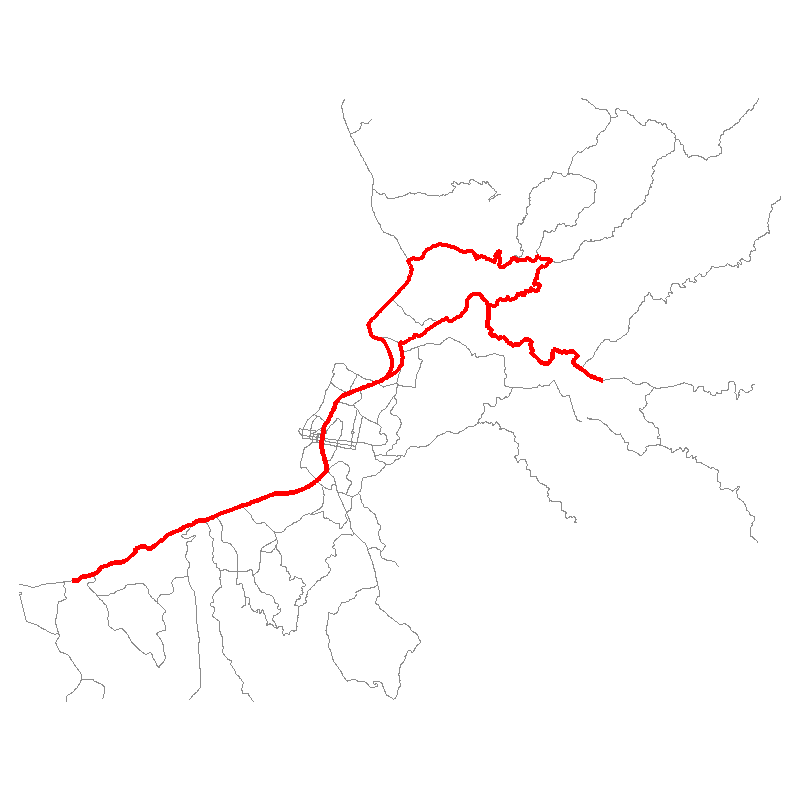

In [8]:
from IPython.display import display

if city and cfg and sampler:
    generator = validate_call(
        "Initialize RouteGenerator",
        True,
        RouteGenerator,
        city_graph=city,
        sampler=sampler
    )

    if generator:
        validate_call("Minimum Points Violation", False, generator.generate, n_points=1)
        route = validate_call("Generate Iligan Route (5 points)", True, generator.generate, n_points=5)

        if route:
            base_img = validate_call("Render base map", True, city.draw, size=800, only_drivable=True)
            context = validate_call("Bounding context", True, city.get_bounds)

            if base_img and context:
                drawn_img = validate_call(
                    "Overlay proposed route",
                    True,
                    route.draw,
                    context=context,
                    image=base_img,
                    color="#FF0000",
                    width=4
                )
                if drawn_img:
                    validate_call("Route draw square check", True, assert_square_image, drawn_img)
                    display(drawn_img)


## **TravelGraph** (in travel_graph.py)

[REJECTED] TravelGraph reject null CityGraph: Safely blocked with ValueError([TRAVEL GRAPH] CityGraph cannot be 
None.)

[REJECTED] TravelGraph reject null RouteGenerator: Safely blocked with ValueError([TRAVEL GRAPH] RouteGenerator 
cannot be None.)

[REJECTED] TravelGraph reject null config: Safely blocked with ValueError([TRAVEL GRAPH] Configuration dictionary 
cannot be None.)

[VALIDATED] TravelGraph initialization: Executed successfully.

[VALIDATED] TravelGraph has routes: Executed successfully.

[VALIDATED] TravelGraph has edges: Executed successfully.

[REJECTED] TravelGraph reject non-square image: Safely blocked with ValueError([TRAVEL GRAPH] Image must be 
square.)

[VALIDATED] Edge type GIF created: Executed successfully.

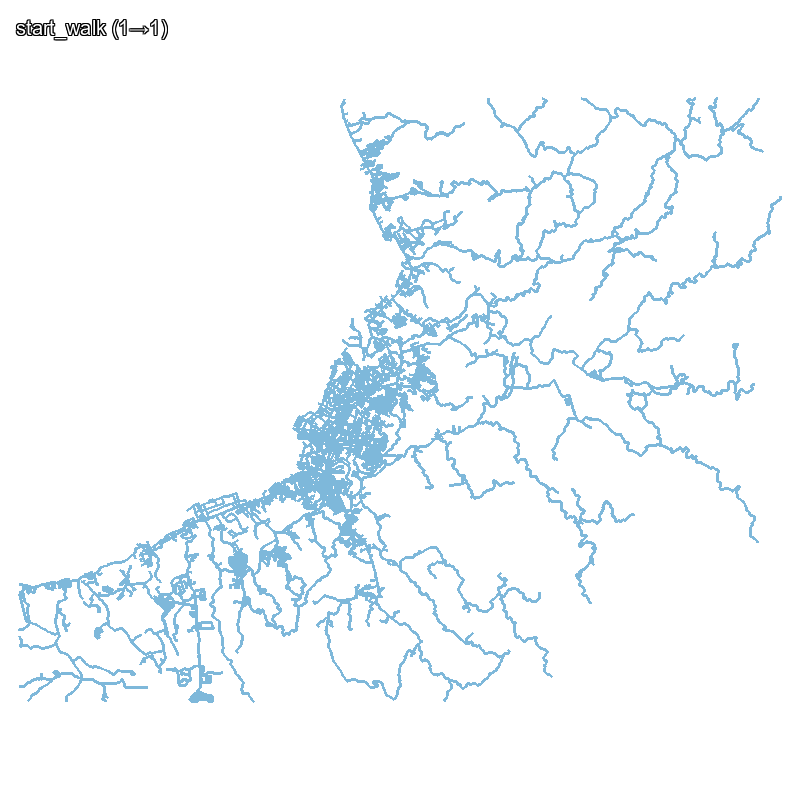

[REJECTED] findShortestJourney reject None: Safely blocked with ValueError([TRAVEL GRAPH] Start and end nodes 
cannot be None.)

Journey with ride found on attempt 1/400: N0067339e804f42d9921029e83f16f220 → N51d15bfb3a99455689c37ef7ba8d404d

[VALIDATED] Journey with at least one ride found: Executed successfully.

Journey edge-by-edge breakdown:

01. WA20184 | wait | L1->L2 | edge_wt=8.50 | cumulative_wt=8.50

...

[VALIDATED] calculateJourneyDistance positive: Executed successfully.

[VALIDATED] calculateJourneyWeight positive: Executed successfully.

[VALIDATED] WA before RI in sequence: Executed successfully.

[VALIDATED] Journey terminates at layer 3: Executed successfully.

[VALIDATED] Journey GIF created: Executed successfully.

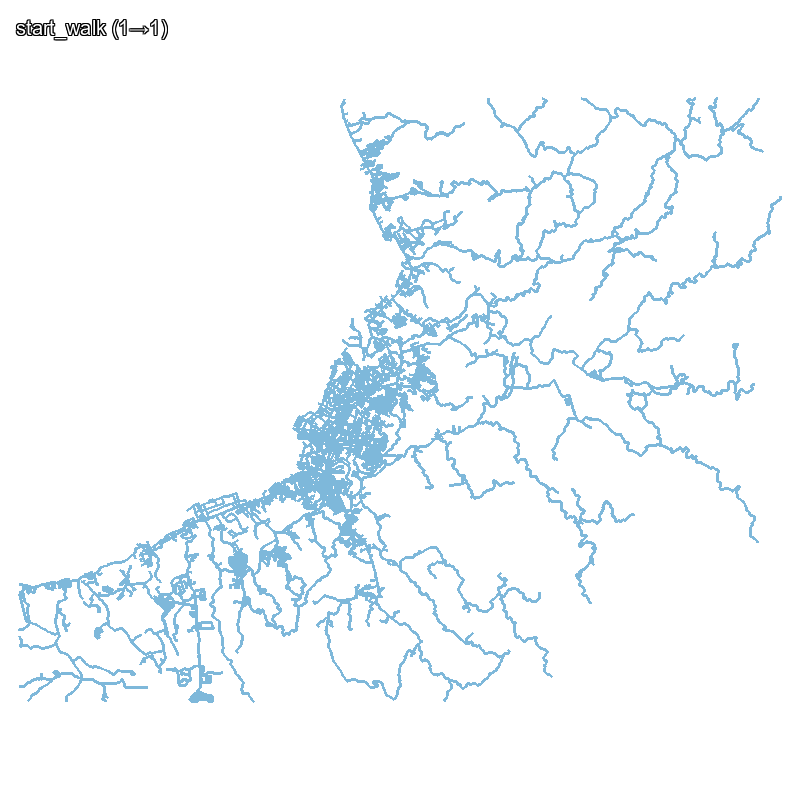

[VALIDATED] TravelGraph 3D journey render: Executed successfully.

[VALIDATED] TravelGraph 3D image dimensions valid: Executed successfully.

3D journey image size: 685x1199

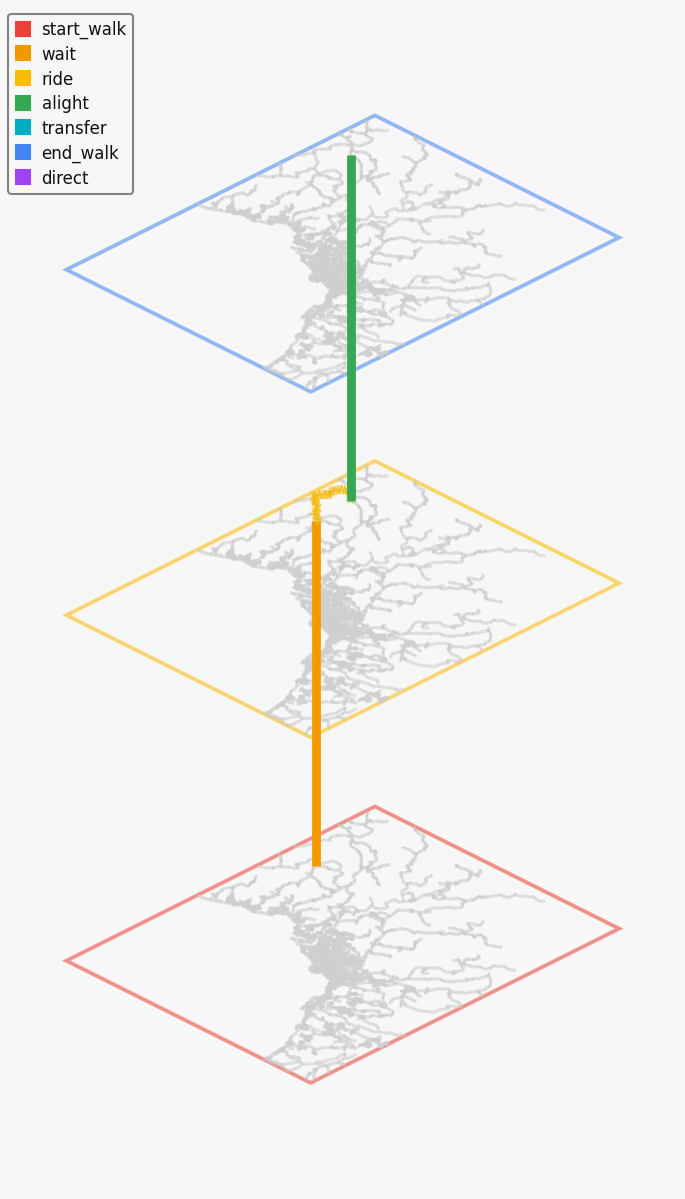

In [ ]:
from utils.travel_graph import TravelGraph
from utils.visualization import draw_all, compile_to_gif
from IPython.display import Image as IPyImage, display
import os

if city and cfg and sampler and generator:
    # ── Negative: mandatory safeguards
    validate_call("TravelGraph reject null CityGraph", False, TravelGraph, cg=None, route_generator=generator, config=cfg["travel_graph"])
    validate_call("TravelGraph reject null RouteGenerator", False, TravelGraph, cg=city, route_generator=None, config=cfg["travel_graph"])
    validate_call("TravelGraph reject null config", False, TravelGraph, cg=city, route_generator=generator, config=None)

    # ── Positive: construction
    tg = validate_call(
        "TravelGraph initialization",
        True, TravelGraph,
        cg=city, route_generator=generator, config=cfg["travel_graph"],
        n_routes=3, n_points=5
    )

    if tg:
        validate_call("TravelGraph has routes", True, assert_true, len(tg.routes) > 0, "No routes generated.")
        validate_call("TravelGraph has edges", True, assert_true, len(tg.travel_graph) > 0, "No edges in travel graph.")

        # ── Negative: draw rejects non-square image
        context = city.get_bounds()
        non_square = Image.new("RGB", (800, 600), "white")
        validate_call("TravelGraph reject non-square image", False, tg.draw, context, non_square)

        base_img = city.draw(size=800, only_drivable=False)

        # ── GIF 1: Edge type showcase (one frame per type, no journey)
        EDGE_TYPES = [
            ("display_walk",     "start_walk (1→1)"),
            ("display_wait",     "wait (1→2)"),
            ("display_ride",     "ride (2→2)"),
            ("display_alight",   "alight (2→3)"),
            ("display_end_walk", "end_walk (3→3)"),
            ("display_transfer", "transfer (3→2)"),
            ("display_direct",   "direct (1→3)"),
        ]

        edge_frames = []
        for flag_name, label in EDGE_TYPES:
            frame_img = tg.draw(context, base_img, **{flag_name: True})
            frame = draw_all([], context, base_image=frame_img, resolution=800, text=label)
            edge_frames.append(frame)

        if edge_frames:
            gif_path = "utils/.cache/travel_graph_layers.gif"
            compile_to_gif(edge_frames, fps=2, export_to=gif_path)
            validate_call("Edge type GIF created", True, assert_true, os.path.exists(gif_path), "GIF not created.")
            display(IPyImage(filename=gif_path))

        # ── Journey query (forced: must include at least one ride edge for testing)
        validate_call("findShortestJourney reject None", False, tg.findShortestJourney, None, None)

        max_ride_attempts = 400
        journey = None
        start_node = None
        end_node = None

        for attempt in range(1, max_ride_attempts + 1):
            candidate_start = sampler.get_point()
            candidate_end = sampler.get_point()
            while candidate_end is candidate_start:
                candidate_end = sampler.get_point()

            candidate_journey = tg.findShortestJourney(candidate_start, candidate_end)
            if candidate_journey and any(e.id[:2] == "RI" for e in candidate_journey):
                start_node = candidate_start
                end_node = candidate_end
                journey = candidate_journey
                print(f"[bold]Journey with ride found on attempt {attempt}/{max_ride_attempts}: {start_node.id} → {end_node.id}[/bold]")
                break

        validate_call(
            "Journey with at least one ride found",
            True,
            assert_true,
            journey is not None,
            f"Could not find a journey with an RI segment after {max_ride_attempts} attempts.",
        )

        if journey:
            edge_type_names = {
                "SW": "start_walk",
                "WA": "wait",
                "RI": "ride",
                "AL": "alight",
                "TR": "transfer",
                "EW": "end_walk",
                "DI": "direct",
            }
            print("[bold cyan]Journey edge-by-edge breakdown:[/bold cyan]")
            type_weight_totals = {}
            running_weight = 0.0
            for idx, e in enumerate(journey, start=1):
                prefix = e.id[:2]
                edge_weight = float(e.weight if e.weight is not None else 0.0)
                running_weight += edge_weight
                edge_type = edge_type_names.get(prefix, e.type or "unknown")
                type_weight_totals[prefix] = type_weight_totals.get(prefix, 0.0) + edge_weight
                print(
                    f"  {idx:02d}. {e.id} | {edge_type} | L{e.start.layer}->L{e.end.layer} | "
                    f"edge_wt={edge_weight:.2f} | cumulative_wt={running_weight:.2f}"
                )

            total_edge_weight = sum(float(e.weight if e.weight is not None else 0.0) for e in journey)
            total_edge_distance = sum(e.getLength() for e in journey if e.id[:2] in {"SW", "RI", "EW"})
            shortest_weight = tg.calculateJourneyWeight(start_node, end_node)
            shortest_distance = tg.calculateJourneyDistance(start_node, end_node)

            print("[bold cyan]Journey weights by type:[/bold cyan]")
            for prefix, wt in sorted(type_weight_totals.items()):
                print(f"  {prefix} ({edge_type_names.get(prefix, 'unknown')}): {wt:.2f}")

            print(f"[bold green]Total journey edge weight:[/bold green] {total_edge_weight:.2f}")
            print(f"[bold green]Total journey weight (A*):[/bold green] {shortest_weight:.2f}")
            print(f"[bold green]Total journey distance from edges:[/bold green] {total_edge_distance:.2f} m")
            print(f"[bold green]Total journey distance (helper):[/bold green] {shortest_distance:.2f} m")

            validate_call(
                "calculateJourneyDistance positive", True,
                assert_true, tg.calculateJourneyDistance(start_node, end_node) > 0,
                "Journey distance is zero or negative."
            )
            validate_call(
                "calculateJourneyWeight positive", True,
                assert_true, tg.calculateJourneyWeight(start_node, end_node) > 0,
                "Journey weight is zero or negative."
            )

            seg_prefixes = [e.id[:2] for e in journey]
            has_ride = "RI" in seg_prefixes
            if has_ride:
                validate_call(
                    "WA before RI in sequence", True,
                    assert_true, seg_prefixes.index("WA") < seg_prefixes.index("RI"),
                    "WA must come before RI."
                )
            validate_call(
                "Journey terminates at layer 3", True,
                assert_true, seg_prefixes[-1] in ["EW", "AL", "DI"],
                f"Journey should end with EW, AL, or DI but ends with '{seg_prefixes[-1]}'."
            )

            # ── GIF 2: Journey overlay (one frame per edge type, journey colored by edge type)
            journey_frames = []
            for flag_name, label in EDGE_TYPES:
                frame_img = tg.draw(context, base_img, journey=journey, **{flag_name: True})
                frame = draw_all([], context, base_image=frame_img, resolution=800, text=label)
                journey_frames.append(frame)

            if journey_frames:
                gif_path = "utils/.cache/journey.gif"
                compile_to_gif(journey_frames, fps=2, export_to=gif_path)
                validate_call("Journey GIF created", True, assert_true, os.path.exists(gif_path), "GIF not created.")
                display(IPyImage(filename=gif_path))

            journey_3d = validate_call(
                "TravelGraph 3D journey render",
                True,
                tg.create_3d,
                journey=journey,
                display_walk=True,
                display_wait=True,
                display_ride=True,
                display_alight=True,
                display_end_walk=True,
                display_transfer=True,
                display_direct=True,
            )
            if journey_3d:
                validate_call(
                    "TravelGraph 3D image dimensions valid",
                    True,
                    assert_true,
                    journey_3d.width > 0 and journey_3d.height > 0,
                    "3D journey image dimensions are invalid."
                )
                print(f"[bold]3D journey image size:[/bold] {journey_3d.width}x{journey_3d.height}")
                display(journey_3d)
